# Experiment No. 7

## Title
**To create an OpenCV-Python program to sharpen a given RGB/Grayscale image**

## Objective
To sharpen both grayscale and RGB images using a convolution mask.

## Mathematical Theory
Sharpening is a spatial filtering process used to enhance edges and fine details by emphasizing high-frequency components of an image.

A common sharpening kernel is:

$$
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 5 & -1 \\
0 & -1 & 0
\end{bmatrix}
$$

For grayscale image:

$$
g(x,y)=\sum_{m=-1}^{1}\sum_{n=-1}^{1} w(m,n)\,f(x+m,y+n)
$$

For RGB image:

$$
g(x,y,c)=\sum_{m=-1}^{1}\sum_{n=-1}^{1} w(m,n)\,f(x+m,y+n,c)
$$

Where:

- $f(x,y)$ = input pixel value  
- $g(x,y)$ = output pixel value  
- $w(m,n)$ = sharpening mask coefficient  
- $c$ = color channel (Red, Green, Blue)

The center pixel is emphasized, while neighboring pixels are subtracted. After convolution, pixel values are clipped to the valid range $0$ to $255$.

## Instruments / Requirements
- Computer or Laptop
- Python
- OpenCV
- NumPy
- Matplotlib
- Input image: `demo_image.jpg`

## Procedure
1. Read the image using OpenCV.
2. If the image is color, convert it from BGR to RGB format.
3. Define the sharpening kernel.
4. Apply convolution on each $3 \times 3$ neighborhood.
5. For RGB image, apply the kernel separately on each color channel.
6. Clip the output values to the range 0–255.
7. Store the sharpened image.
8. Display the original and sharpened images.

## Output
- Original image (Grayscale/RGB)
- Sharpened image

## Result
The sharpened image shows clearer edges and improved visibility of fine details. In RGB images, sharpening is applied to each channel separately, producing a sharper color image.

## Conclusion
Sharpening is an important image enhancement technique that improves image clarity by emphasizing edge and detail information. It works effectively for both grayscale and RGB images.

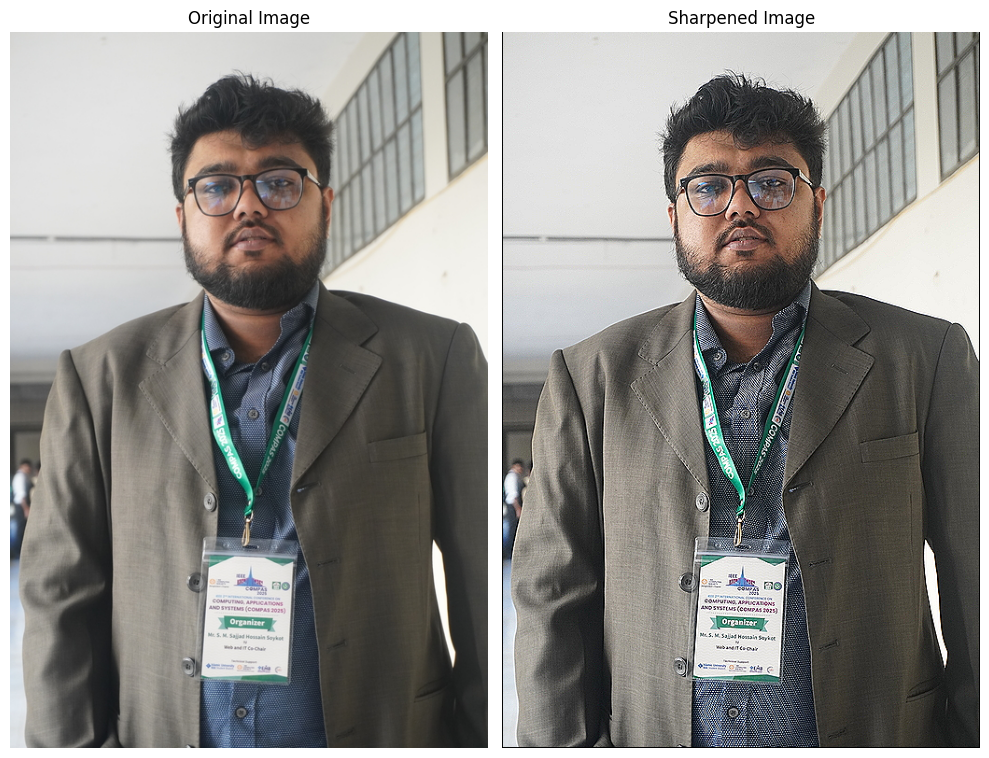

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('demo_image.jpg')

# Sharpening kernel
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

# Check grayscale or color
if len(img.shape) == 2:
    # Grayscale image
    h, w = img.shape
    sharpened = np.zeros((h, w), dtype=np.uint8)

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            s = 0
            for m in range(-1, 2):
                for n in range(-1, 2):
                    s += int(img[i + m, j + n]) * kernel[m + 1, n + 1]

            if s < 0:
                s = 0
            elif s > 255:
                s = 255

            sharpened[i, j] = s

    display_img = img
    display_sharp = sharpened
    cmap = 'gray'

else:
    # Color image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape
    sharpened = np.zeros((h, w, c), dtype=np.uint8)

    for k in range(c):
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                s = 0
                for m in range(-1, 2):
                    for n in range(-1, 2):
                        s += int(img[i + m, j + n, k]) * kernel[m + 1, n + 1]

                if s < 0:
                    s = 0
                elif s > 255:
                    s = 255

                sharpened[i, j, k] = s

    display_img = img
    display_sharp = sharpened
    cmap = None

# Display result
plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(display_img, cmap=cmap)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(display_sharp, cmap=cmap)
plt.title("Sharpened Image")
plt.axis("off")

plt.tight_layout()
plt.savefig('Exp7_Output.png')  # Save full figure
plt.show()

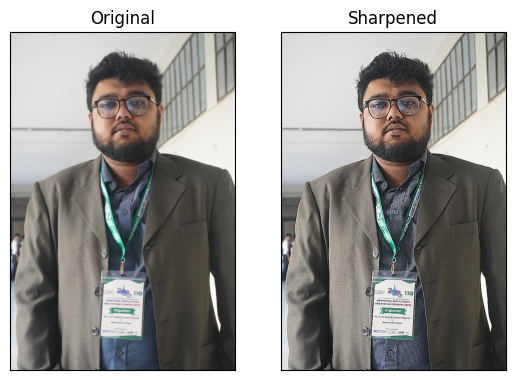

In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('demo_image.jpg')

kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

sharp = cv2.filter2D(img, -1, kernel)

plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original')
plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(cv2.cvtColor(sharp, cv2.COLOR_BGR2RGB)), plt.title('Sharpened')
plt.xticks([]), plt.yticks([])

plt.show()